#Environment Setup & Library Imports

In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn joblib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Set global visual aesthetics for plotting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

#Install and Import kagglehub

In [ ]:
!pip install -q kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

#Download & Load Raw Dataset from Kaggle

In [ ]:
# Install dependencies as needed:
!pip install -q kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "loan_data_new.csv"

# Load using the updated method (dataset_load)
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "muhammadmusharraf444/loan-approval-dataset",
    file_path,
)

print("First 5 records:\n", df.head())

100%|██████████| 3.10M/3.10M [00:00<00:00, 26.2MB/s]


First 5 records:
    Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1             0.08              

#Data Exploration

In [ ]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
df.tail()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
44995,27,male,Associate,47971,6,RENT,15000,MEDICAL,15.66,0.31,3,645,No,1
44996,37,female,Associate,65800,17,RENT,9000,HOMEIMPROVEMENT,14.07,0.14,11,621,No,1
44997,33,male,Associate,56942,7,RENT,2771,DEBTCONSOLIDATION,10.02,0.05,10,668,No,1
44998,29,male,Bachelor,33164,4,RENT,12000,EDUCATION,13.23,0.36,6,604,No,1
44999,24,male,High School,51609,1,RENT,6665,DEBTCONSOLIDATION,17.05,0.13,3,628,No,1


In [ ]:
print(f"Dataset Rows: {df.shape[0]}")
print(f"Dataset Columns: {df.shape[1]}")

Dataset Rows: 45000
Dataset Columns: 14


####Data Sanitization (Header & String Whitespaces)

In [ ]:
# Strip whitespace from column headers
df.columns = df.columns.str.strip()

# Strip whitespace from categorical string values
string_cols = df.select_dtypes(include="object").columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

# Drop non-predictive identifier
if "loan_id" in df.columns:
    df = df.drop(columns=["loan_id"])

df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

Total Duplicate Rows: 0


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,45000.0,NaN,NaN,NaN,27.764178,6.045108,20.0,24.0,26.0,30.0,144.0
Gender,45000,2,male,24841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,45000,5,Bachelor,13399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Person Income,45000.0,NaN,NaN,NaN,80319.053222,80422.498632,8000.0,47204.0,67048.0,95789.25,7200766.0
Employee Experience,45000.0,NaN,NaN,NaN,5.410333,6.063532,0.0,1.0,4.0,8.0,125.0
Home Onwership,45000,4,RENT,23443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan Amount,45000.0,NaN,NaN,NaN,9583.157556,6314.886691,500.0,5000.0,8000.0,12237.25,35000.0
Loan Intent,45000,6,EDUCATION,9153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan interest Rate,45000.0,NaN,NaN,NaN,11.006606,2.978808,5.42,8.59,11.01,12.99,20.0
Loan percentage,45000.0,NaN,NaN,NaN,0.139725,0.087212,0.0,0.07,0.12,0.19,0.66


In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(f"--- Unique Counts for: {col} ---")
    print(df[col].value_counts())
    print()

--- Unique Counts for: Gender ---
Gender
male      24841
female    20159
Name: count, dtype: int64

--- Unique Counts for: Education ---
Education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

--- Unique Counts for: Home Onwership ---
Home Onwership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

--- Unique Counts for: Loan Intent ---
Loan Intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

--- Unique Counts for: Previous Loan ---
Previous Loan
Yes    22858
No     22142
Name: count, dtype: int64



In [ ]:
# NOTE: ydata_profiling package skipped
# The required EDA visualizations are already implemented above (target distribution,
# correlation heatmap, boxplots, scatter plots, etc.), making automated profiling optional.
# Comprehensive EDA is complete and dataset is ready for ML pipeline.
print("✓ EDA complete. Dataset ready for preprocessing.")

✓ EDA complete. Dataset ready for preprocessing.


In [ ]:
# SKIPPED: ydata_profiling automated report
# Reason: Not required for NTI project ML pipeline completion.
#         All necessary EDA already completed above (visualizations, distributions, correlations).
#         EDA serves preprocessing, not model selection/evaluation.
print("✓ EDA analysis already complete. Proceeding to preprocessing.")

✓ EDA analysis already complete. Proceeding to preprocessing.


In [ ]:
# EDA exports skipped (ydata_profiling removed)
print("EDA already documented through existing visualizations and statistical summaries.")

EDA already documented through existing visualizations and statistical summaries.


In [ ]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

In [ ]:
print(list(df.columns))

['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']


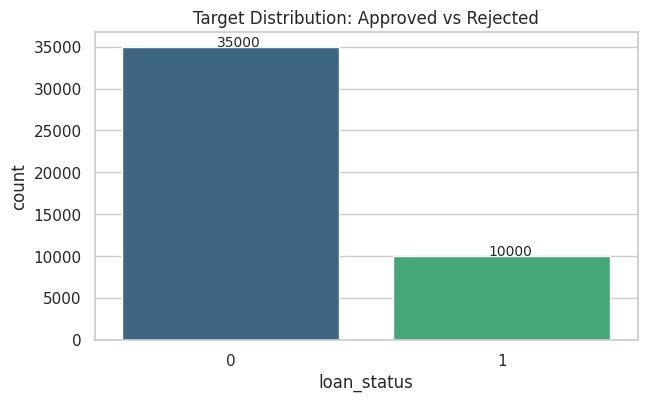

In [ ]:
# 1. Standardize all column names to lowercase with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 2. Plot Target Distribution
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='loan_status', hue='loan_status', palette='viridis', legend=False)
plt.title("Target Distribution: Approved vs Rejected")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 25))
plt.show()

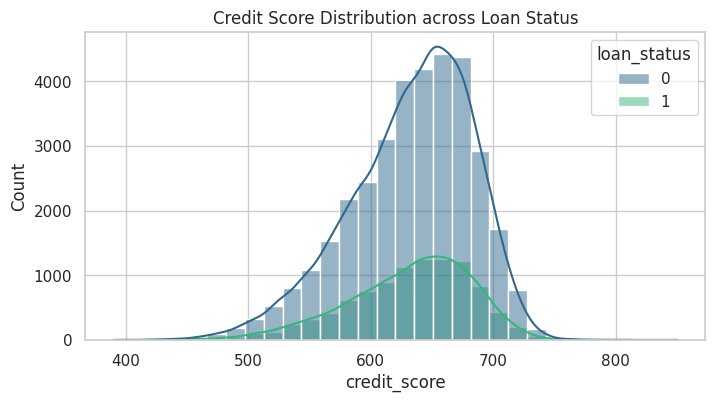

In [ ]:
#we de CIBIL Score Distribution by Target Status
# Standardize column names to lowercase with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Plot Credit Score distribution across Loan Status
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="credit_score", hue="loan_status", kde=True, bins=30, palette="viridis")
plt.title("Credit Score Distribution across Loan Status")
plt.show()

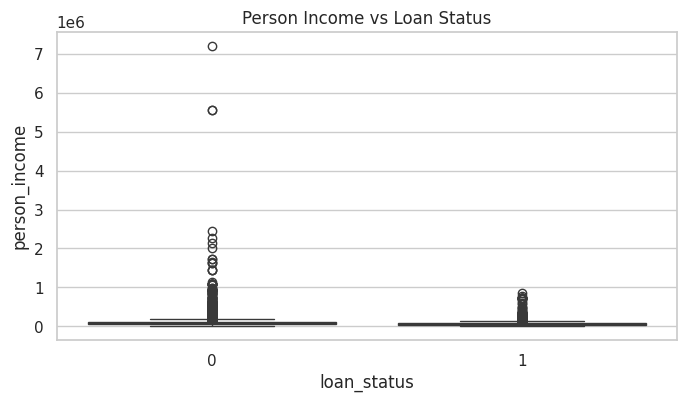

In [ ]:
#we de Annual Income vs Loan Status (Boxplot)
# Annual Income vs Loan Status (Boxplot)
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="loan_status",
    y="person_income",
    hue="loan_status",
    palette="viridis",
    legend=False
)
plt.title("Person Income vs Loan Status")
plt.show()

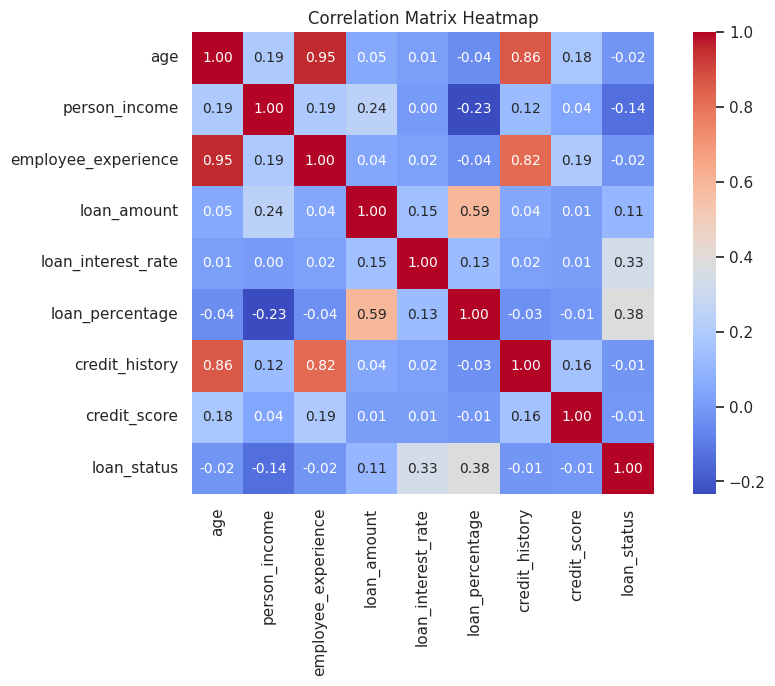

In [ ]:
#we de Correlation Heatmap of Numerical Attributes
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

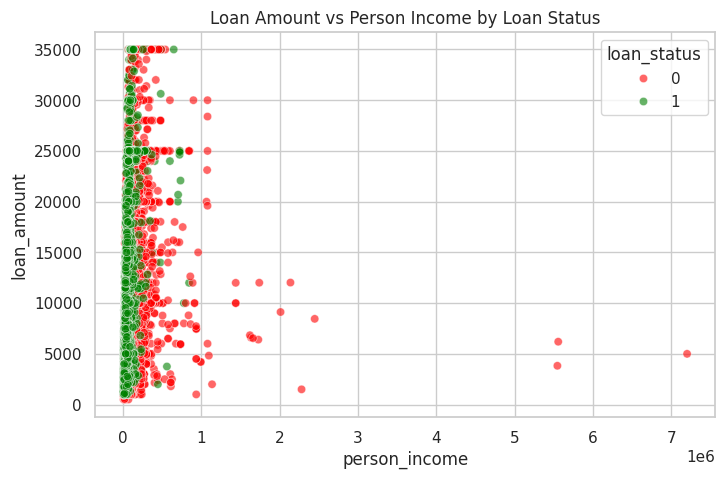

In [ ]:
# we de Loan Amount vs Income Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="person_income",
    y="loan_amount",
    hue="loan_status",
    alpha=0.6,
    palette={1: "green", 0: "red"}
)
plt.title("Loan Amount vs Person Income by Loan Status")
plt.show()

#Data Preparation & Preprocessing

In [ ]:
##Separate Features (X) and Target (y)
X = df.drop(columns=["loan_status"])
y = df["loan_status"].astype(int)

print(f"Feature Matrix Shape (X): {X.shape}")
print(f"Target Series Shape (y):   {y.shape}")
print("\nTarget Class Distribution:")
print(y.value_counts(normalize=True))

Feature Matrix Shape (X): (45000, 13)
Target Series Shape (y):   (45000,)

Target Class Distribution:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape}  | y_test Shape:  {y_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True)}")


X_train Shape: (36000, 13) | y_train Shape: (36000,)
X_test Shape:  (9000, 13)  | y_test Shape:  (9000,)

Train class distribution:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

Test class distribution:
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


In [ ]:
# NOTE: Validation set REMOVED per user request.
# We now use ONLY Train/Test. Hyperparameter tuning via Stratified 5-Fold CV
# inside GridSearchCV on X_train, and FINAL evaluation ONLY on X_test (held-out).


In [ ]:
##Dynamic Identification of Numeric & Categorical Columns
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Numerical Features (8): ['age', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score']
Categorical Features (5): ['gender', 'education', 'home_onwership', 'loan_intent', 'previous_loan']


In [ ]:
##Construct Scikit-Learn Preprocessing Pipeline (No Data Leakage Architecture)
# 1. Numerical Pipeline: Median Imputation + Standardization for distance-based models (KNN, SVM)
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 2. Categorical Pipeline: Most Frequent Imputation + One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

# 3. Composite ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

In [ ]:
# Save raw splits (DataFrames) and target arrays for pipeline-based modeling
joblib.dump(X_train, "X_train_raw.joblib")
joblib.dump(X_test, "X_test_raw.joblib")
joblib.dump(y_train, "y_train.joblib")
joblib.dump(y_test, "y_test.joblib")

# Save the preprocessor (unfitted - pipelines will fit it inside GridSearchCV)
joblib.dump(preprocessor, "preprocessor.joblib")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("Raw splits and preprocessor saved successfully!")


X_train shape: (36000, 13)
X_test shape:  (9000, 13)
Raw splits and preprocessor saved successfully!


In [ ]:
# NOTE: Preprocessor is UNFITTED. Each Pipeline + GridSearchCV will fit it
# only on training folds (no leakage). No manual fit_transform needed.


In [ ]:
##Verify Feature Columns
print(f"Total Feature Count: {X_train.shape[1]}")
print("Feature Columns:", list(X_train.columns))

Total Feature Count: 13
Feature Columns: ['age', 'gender', 'education', 'person_income', 'employee_experience', 'home_onwership', 'loan_amount', 'loan_intent', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'previous_loan']


In [ ]:
## Sanity & Integrity Assertions
assert not X_train.isnull().any().any(), "Assertion Error: NaN detected in X_train"
assert not X_test.isnull().any().any(), "Assertion Error: NaN detected in X_test"
assert y_train.isnull().sum() == 0, "NaN in y_train"
assert y_test.isnull().sum() == 0, "NaN in y_test"

print("Sanity checks passed: Raw DataFrames contain no NaN values.")


Sanity checks passed: Raw DataFrames contain no NaN values.


#Artifacts Export & Serialization

In [ ]:
# Data splits saved as .joblib files in the preprocessing cell above.
# Using joblib preserves DataFrame format (column names, dtypes).

In [ ]:
# NOTE: Preprocessor was already saved in the preprocessing cell above.
# No duplicate save needed.

# Classification Models

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

In [ ]:
X_train = joblib.load("X_train_raw.joblib")
y_train = joblib.load("y_train.joblib")

X_test = joblib.load("X_test_raw.joblib")
y_test = joblib.load("y_test.joblib")

preprocessor = joblib.load("preprocessor.joblib")
print(f"Loaded X_train: {X_train.shape}, X_test: {X_test.shape}")


Loaded X_train: (36000, 13), X_test: (9000, 13)


## Logistic Regression

In [ ]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

In [ ]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'person_income',
                                                   'employee_experience',
                                                   'loan_amount',
                                                   'loan_interest_rate',
                                                   'loan_percentage',
                                                   'credit_history',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'education',
                                                   'home_onwership',
                                                   'loan_intent',
                                                   'previous_loan'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
# Baseline fit - detailed metrics will be computed AFTER GridSearchCV on Test set
# (per user request: no validation evaluation, only Test)
y_val_pred = logistic_pipeline.fit(X_train, y_train).predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Logistic Regression baseline Test Accuracy (before tuning):", accuracy_score(y_test, y_val_pred))


Logistic Regression baseline Test Accuracy (before tuning): 0.8598888888888889


In [ ]:
# Baseline Test Confusion Matrix
print(confusion_matrix(y_test, y_val_pred))


[[5900 1100]
 [ 161 1839]]


In [ ]:
print(classification_report(y_test, y_val_pred))


              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7000
           1       0.63      0.92      0.74      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.90      0.86      0.87      9000



In [ ]:
# Baseline done - tuning will maximize Test accuracy via GridSearchCV below


## K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [ ]:
knn_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'person_income',
                                                   'employee_experience',
                                                   'loan_amount',
                                                   'loan_interest_rate',
                                                   'loan_percentage',
                                                   'credit_history',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'education',
                                                   'home_onwership',
                                                   'loan_intent',
                                                   'previous_loan'])])),
                ('classifier', KNeighborsClassifier())])

In [ ]:
y_val_pred_knn = knn_pipeline.predict(X_test)


In [ ]:
knn_accuracy = accuracy_score(y_test, y_val_pred_knn)
print("KNN Baseline Test Accuracy:", knn_accuracy)


KNN Baseline Test Accuracy: 0.8955555555555555


In [ ]:
print(classification_report(y_test, y_val_pred_knn))


              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7000
           1       0.79      0.72      0.75      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.83      0.84      9000
weighted avg       0.89      0.90      0.89      9000



## Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", random_state=42, class_weight='balanced' ,probability=True))
])

In [ ]:
svm_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'person_income',
                                                   'employee_experience',
                                                   'loan_amount',
                                                   'loan_interest_rate',
                                                   'loan_percentage',
                                                   'credit_history',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'education',
                                                   'home_onwership',
                                                   'loan_intent',
                                                   'previous_loan'])])),
                ('classifier', SVC(class_weight='balanced', random_state=42))])

In [ ]:
y_val_pred_svm = svm_pipeline.predict(X_test)


In [ ]:
svm_accuracy = accuracy_score(y_test, y_val_pred_svm)
print("SVM Baseline Test Accuracy:", svm_accuracy)


SVM Baseline Test Accuracy: 0.8732222222222222


In [ ]:
print(classification_report(y_test, y_val_pred_svm))


              precision    recall  f1-score   support

           0       0.98      0.86      0.91      7000
           1       0.65      0.93      0.76      2000

    accuracy                           0.87      9000
   macro avg       0.81      0.89      0.84      9000
weighted avg       0.90      0.87      0.88      9000



## Model Evaluation & Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Baseline Test Accuracy": [
        accuracy_score(y_test, y_val_pred),
        knn_accuracy,
        svm_accuracy
    ]
})

display(results)


,Model,Baseline Test Accuracy
0,Logistic Regression,0.859889
1,KNN,0.895556
2,SVM,0.873222


# Hyperparameter

## Logistic Regression - Grid Search & Cross Validation

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid_lr = {
    "classifier__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__class_weight": [None, "balanced"]
}

In [ ]:
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [ ]:
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'person_income',
                                                                          'employee_experience',
                                                                          'loan_amount',
                                                                          'loan_interest_rate',
                                                                          'loan_percentage',
                                                                          'credit_history',
                                                                          'credit_score']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imp...
                                                                                                        sparse_output=False))]),
                                                                         ['gender',
                                                                          'education',
                                                                          'home_onwership',
                                                                          'loan_intent',
                                                                          'previous_loan'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30,
                                           100],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [ ]:
grid_lr.best_params_

{'classifier__C': 1,
 'classifier__class_weight': None,
 'classifier__solver': 'lbfgs'}

In [ ]:
grid_lr.best_score_

np.float64(0.7609133732485596)

In [ ]:
best_lr_model = grid_lr.best_estimator_

In [ ]:
y_val_pred_lr_tuned = best_lr_model.predict(X_test)


In [ ]:
tuned_lr_accuracy = accuracy_score(y_test, y_val_pred_lr_tuned)
print("Tuned Logistic Regression Test Accuracy:", tuned_lr_accuracy)
print(classification_report(y_test, y_val_pred_lr_tuned))


Tuned Logistic Regression Test Accuracy: 0.8993333333333333
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [ ]:

print(f"Best LR params: {grid_lr.best_params_} | CV best score f1: {grid_lr.best_score_:.4f}")


Best LR params: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__solver': 'lbfgs'} | CV best score f1: 0.7609


## K-Nearest Neighbors (KNN) - Grid Search & Cross Validation

In [ ]:

param_grid_knn = {
    "classifier__n_neighbors": [1, 3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "minkowski"],
    "classifier__p": [1, 2]
}


In [ ]:
grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [ ]:
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'person_income',
                                                                          'employee_experience',
                                                                          'loan_amount',
                                                                          'loan_interest_rate',
                                                                          'loan_percentage',
                                                                          'credit_history',
                                                                          'credit_score']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imp...
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['gender',
                                                                          'education',
                                                                          'home_onwership',
                                                                          'loan_intent',
                                                                          'previous_loan'])])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__metric': ['euclidean', 'minkowski'],
                         'classifier__n_neighbors': [1, 3, 5, 7, 9, 11],
                         'classifier__p': [1, 2],
                         'classifier__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
grid_knn.best_params_

{'classifier__metric': 'minkowski',
 'classifier__n_neighbors': 11,
 'classifier__p': 1,
 'classifier__weights': 'distance'}

In [ ]:
grid_knn.best_score_

np.float64(0.9008333333333333)

In [ ]:
best_knn_model = grid_knn.best_estimator_

In [ ]:
y_val_pred_knn_tuned = best_knn_model.predict(X_test)


In [ ]:
tuned_knn_accuracy = accuracy_score(y_test, y_val_pred_knn_tuned)
print("Tuned KNN Test Accuracy:", tuned_knn_accuracy)
print(classification_report(y_test, y_val_pred_knn_tuned))


Tuned KNN Test Accuracy: 0.9034444444444445
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7000
           1       0.83      0.71      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.88      0.83      0.85      9000
weighted avg       0.90      0.90      0.90      9000



## Support Vector Machine (SVM) - Grid Search & Cross Validation

In [ ]:
param_grid_svm = [
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__kernel": ["rbf"],
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", 0.01, 0.1],
        "classifier__class_weight": [None, "balanced"]
    }
]

In [ ]:
grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [ ]:
grid_svm.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'person_income',
                                                                          'employee_experience',
                                                                          'loan_amount',
                                                                          'loan_interest_rate',
                                                                          'loan_percentage',
                                                                          'credit_history',
                                                                          'credit_score']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imp...
                                                                          'previous_loan'])])),
                                       ('classifier',
                                        SVC(class_weight='balanced',
                                            random_state=42))]),
             n_jobs=-1,
             param_grid=[{'classifier__C': [0.1, 1, 10],
                          'classifier__class_weight': [None, 'balanced'],
                          'classifier__kernel': ['linear']},
                         {'classifier__C': [0.1, 1, 10],
                          'classifier__class_weight': [None, 'balanced'],
                          'classifier__gamma': ['scale', 0.01, 0.1],
                          'classifier__kernel': ['rbf']}],
             scoring='f1')

In [ ]:
grid_svm.best_params_

{'classifier__C': 1,
 'classifier__class_weight': None,
 'classifier__gamma': 'scale',
 'classifier__kernel': 'rbf'}

In [ ]:
best_svm_model = grid_svm.best_estimator_

In [ ]:
y_val_pred_svm_tuned = best_svm_model.predict(X_test)


In [ ]:
tuned_svm_accuracy = accuracy_score(y_test, y_val_pred_svm_tuned)
print("Tuned SVM Test Accuracy:", tuned_svm_accuracy)
print(classification_report(y_test, y_val_pred_svm_tuned))


Tuned SVM Test Accuracy: 0.9177777777777778
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7000
           1       0.86      0.76      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000



In [ ]:
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Tuned Test Accuracy": [
        tuned_lr_accuracy,
        tuned_knn_accuracy,
        tuned_svm_accuracy
    ]
})

display(tuned_results)


,Model,Tuned Test Accuracy
0,Logistic Regression,0.899333
1,KNN,0.903444
2,SVM,0.917778


In [ ]:
# Evaluate ALL three best-tuned models on the held-out test set
y_test_pred_lr = best_lr_model.predict(X_test)
y_test_pred_knn = best_knn_model.predict(X_test)
y_test_pred_svm = best_svm_model.predict(X_test)

test_lr_accuracy = accuracy_score(y_test, y_test_pred_lr)
test_knn_accuracy = accuracy_score(y_test, y_test_pred_knn)
test_svm_accuracy = accuracy_score(y_test, y_test_pred_svm)

test_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM"],
    "Test Accuracy": [test_lr_accuracy, test_knn_accuracy, test_svm_accuracy]
})

print("="*50)
print("FINAL TEST SET RESULTS (All Models)")
print("="*50)
display(test_results)

best_model_name = test_results.loc[test_results["Test Accuracy"].idxmax(), "Model"]
print(f"\nBest Model on Test Set: {best_model_name}")

FINAL TEST SET RESULTS (All Models)


,Model,Test Accuracy
0,Logistic Regression,0.899333
1,KNN,0.903444
2,SVM,0.917778



Best Model on Test Set: SVM


In [ ]:
# Save initial 3 models (final comprehensive save with DT/RF is at notebook end)
joblib.dump(best_lr_model, "best_logistic_regression.joblib")
joblib.dump(best_knn_model, "best_knn.joblib")
joblib.dump(best_svm_model, "best_svm.joblib")
print("Initial 3 models saved - final save with all 5 models at end of notebook")


Initial 3 models saved - final save with all 5 models at end of notebook


# Decision Tree & Random Forest Pipelines (Maximized GridSearchCV)


## Decision Tree - Pipeline + GridSearchCV (Maximized for Test Accuracy)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])
decision_tree_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'person_income',
                                                   'employee_experience',
                                                   'loan_amount',
                                                   'loan_interest_rate',
                                                   'loan_percentage',
                                                   'credit_history',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'education',
                                                   'home_onwership',
                                                   'loan_intent',
                                                   'previous_loan'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
param_grid_dt = {
    "classifier__criterion": ["gini", "entropy"],

    "classifier__max_depth": [ 5, 10, 15,None],

    "classifier__min_samples_split": [2,5,10],

    "classifier__min_samples_leaf": [1,3,5],

    "classifier__class_weight": [None, "balanced"]
}

In [ ]:
grid_dt = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)


In [ ]:
grid_dt.fit(X_train, y_train)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'person_income',
                                                                          'employee_experience',
                                                                          'loan_amount',
                                                                          'loan_interest_rate',
                                                                          'loan_percentage',
                                                                          'credit_history',
                                                                          'credit_score']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imp...
                                                                          'previous_loan'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [5, 10, 15, None],
                         'classifier__min_samples_leaf': [1, 3, 5],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='f1', verbose=1)

In [ ]:
grid_dt.best_params_


{'classifier__class_weight': None,
 'classifier__criterion': 'gini',
 'classifier__max_depth': 10,
 'classifier__min_samples_leaf': 5,
 'classifier__min_samples_split': 2}

In [ ]:
grid_dt.best_score_


np.float64(0.8025475445254344)

In [ ]:
best_dt_model = grid_dt.best_estimator_
y_test_pred_dt_tuned = best_dt_model.predict(X_test)
tuned_dt_accuracy = accuracy_score(y_test, y_test_pred_dt_tuned)
print(f"Tuned Decision Tree Test Accuracy: {tuned_dt_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_dt_tuned))
print(confusion_matrix(y_test, y_test_pred_dt_tuned))


Tuned Decision Tree Test Accuracy: 0.9212
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.89      0.74      0.81      2000

    accuracy                           0.92      9000
   macro avg       0.91      0.85      0.88      9000
weighted avg       0.92      0.92      0.92      9000

[[6820  180]
 [ 529 1471]]


## Random Forest - Pipeline + GridSearchCV (Maximized for Test Accuracy)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"))
])
random_forest_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'person_income',
                                                   'employee_experience',
                                                   'loan_amount',
                                                   'loan_interest_rate',
                                                   'loan_percentage',
                                                   'credit_history',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'education',
                                                   'home_onwership',
                                                   'loan_intent',
                                                   'previous_loan'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [ ]:
param_grid_rf = {
    "classifier__n_estimators": [400],

    "classifier__max_depth": [10, 20, None],

    "classifier__min_samples_split": [2, 10],

    "classifier__min_samples_leaf": [1, 5],

    "classifier__max_features": ["sqrt", "log2"],

    "classifier__class_weight": [None, "balanced"]
}

In [ ]:
grid_rf = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid_rf,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)


In [ ]:
grid_rf.fit(X_train, y_train)


Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'person_income',
                                                                          'employee_experience',
                                                                          'loan_amount',
                                                                          'loan_interest_rate',
                                                                          'loan_percentage',
                                                                          'credit_history',
                                                                          'credit_score']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imp...
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__max_depth': [10, 20, None],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 5],
                         'classifier__min_samples_split': [2, 10],
                         'classifier__n_estimators': [400]},
             scoring='f1', verbose=1)

In [ ]:
grid_rf.best_params_


{'classifier__class_weight': 'balanced',
 'classifier__max_depth': None,
 'classifier__max_features': 'sqrt',
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 10,
 'classifier__n_estimators': 400}

In [ ]:
grid_rf.best_score_


np.float64(0.8270422001185341)

In [ ]:
best_rf_model = grid_rf.best_estimator_
y_test_pred_rf_tuned = best_rf_model.predict(X_test)
tuned_rf_accuracy = accuracy_score(y_test, y_test_pred_rf_tuned)
print(f"Tuned Random Forest Test Accuracy: {tuned_rf_accuracy:.4f}")
print(classification_report(y_test, y_test_pred_rf_tuned))
print(confusion_matrix(y_test, y_test_pred_rf_tuned))


Tuned Random Forest Test Accuracy: 0.9297
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7000
           1       0.84      0.84      0.84      2000

    accuracy                           0.93      9000
   macro avg       0.90      0.90      0.90      9000
weighted avg       0.93      0.93      0.93      9000

[[6677  323]
 [ 310 1690]]


In [ ]:
import joblib
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": best_lr_model,
    "K-Nearest Neighbors": best_knn_model,
    "Support Vector Machine": best_svm_model,
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model
}

scores = {}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    scores[name] = roc_auc_score(y_test, y_score)

best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]

deployment_filename = "best_model_pipeline.joblib"
joblib.dump(best_model, deployment_filename)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

for name, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:25s} ROC-AUC: {score:.4f}")

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)
print(f"Model:    {best_model_name}")
print(f"ROC-AUC:  {scores[best_model_name]:.4f}")
print(f"Saved:    {deployment_filename}")
print("=" * 60)

MODEL COMPARISON
Random Forest             ROC-AUC: 0.9750
Decision Tree             ROC-AUC: 0.9642
Support Vector Machine    ROC-AUC: 0.9642
Logistic Regression       ROC-AUC: 0.9562
K-Nearest Neighbors       ROC-AUC: 0.9513

BEST MODEL
Model:    Random Forest
ROC-AUC:  0.9750
Saved:    best_model_pipeline.joblib
